In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes

In [19]:
diabetes = load_diabetes()

In [20]:
# Convert to DataFrame for easier manipulation
data = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
data['Progression'] = diabetes.target

In [21]:
# Display initial data info
print("Dataset Head:")
print(data.head())
print("\nDataset Shape:", data.shape)

Dataset Head:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  Progression  
0 -0.002592  0.019907 -0.017646        151.0  
1 -0.039493 -0.068332 -0.092204         75.0  
2 -0.002592  0.002861 -0.025930        141.0  
3  0.034309  0.022688 -0.009362        206.0  
4 -0.002592 -0.031988 -0.046641        135.0  

Dataset Shape: (442, 11)


In [22]:
# 3. Check for missing values
print("\nMissing Values:\n", data.isnull().sum())


Missing Values:
 age            0
sex            0
bmi            0
bp             0
s1             0
s2             0
s3             0
s4             0
s5             0
s6             0
Progression    0
dtype: int64


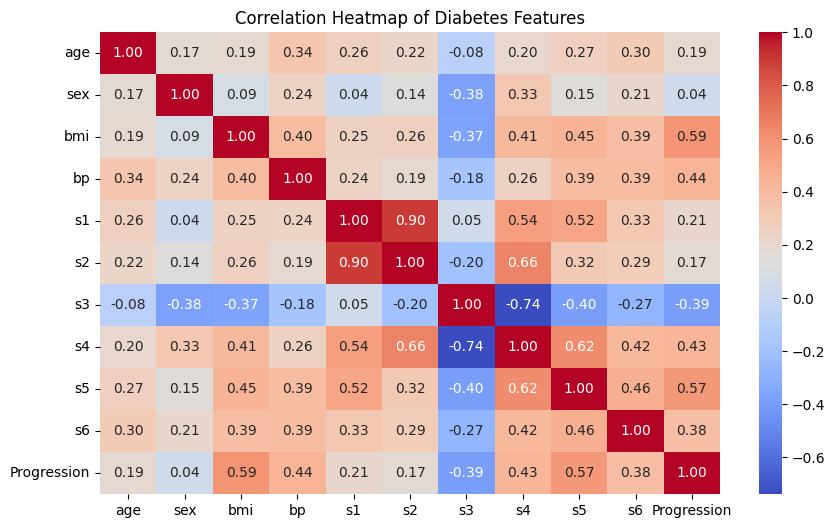

In [23]:
# VISUAL 1: Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Diabetes Features')
plt.show()

In [24]:
# 4. Features & Target
# 'Progression' is the target variable (quantitative measure of disease progression)
X = data.drop('Progression', axis=1)
y = data['Progression']

In [25]:
# 5. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# 6. Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
# 7. Build Linear Regression Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [29]:
# 8. Predictions
y_pred = model.predict(X_test_scaled)

In [30]:
# 9. Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [31]:
print("\n--- Model Evaluation ---")
print("Intercept:", model.intercept_)
print("Mean Squared Error:", mse)
print("R² Score:", r2)


--- Model Evaluation ---
Intercept: 153.73654390934846
Mean Squared Error: 2900.1936284934823
R² Score: 0.45260276297191926


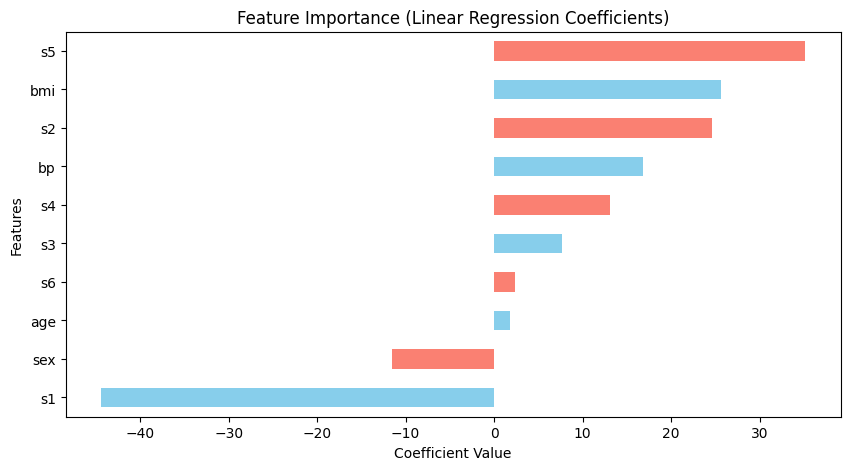

In [32]:
# VISUAL 2: Feature Importance (Model Coefficients)
feature_importance = pd.Series(model.coef_, index=X.columns)
plt.figure(figsize=(10, 5))
feature_importance.sort_values().plot(kind='barh', color=['skyblue', 'salmon'])
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.show()

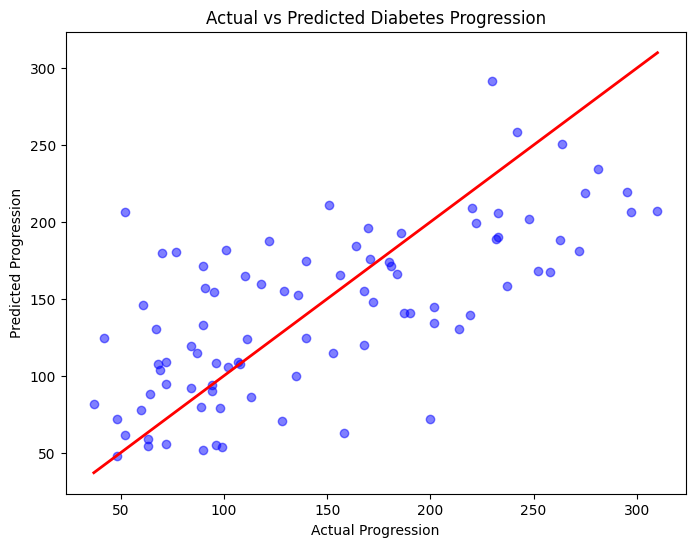

In [34]:
# 10. Visualization: Predicted vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2)
plt.xlabel('Actual Progression')
plt.ylabel('Predicted Progression')
plt.title('Actual vs Predicted Diabetes Progression')
plt.show()

In [35]:
# 11. Make a Single Prediction
# The diabetes dataset features are: [age, sex, bmi, bp, s1, s2, s3, s4, s5, s6]
# We create a sample input (all zero-mean scaled values for simplicity in this example)
sample_input = np.array([[0.05, -0.04, 0.03, 0.01, -0.02, -0.01, -0.04, 0.01, 0.05, 0.02]])

In [36]:
# Scale using the same scaler
sample_input_scaled = scaler.transform(sample_input)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [39]:
# Predict
predicted_value = model.predict(sample_input_scaled)[0]
print(f"\nPredicted Disease Progression Score: {predicted_value:.2f}")


Predicted Disease Progression Score: 230.12
